In [1]:
import torch
import time
import warnings
import os

from device import setup_device
from utk_dataset import UTKFaceDataset
from model import Encoder
from loss import *
from utils import *
from train_encoder import *
from visualization import *

In [2]:
warnings.filterwarnings("ignore", message=".*force_all_finite.*")

from numba.core.errors import NumbaWarning
warnings.filterwarnings("ignore", category=NumbaWarning)

warnings.filterwarnings("ignore", message=".*verbose parameter is deprecated.*")

In [3]:
device, data_parallel = setup_device(use_gpu_1_only=False)

✅ CUDA is available: 2 GPU(s) visible


In [4]:
backbone_model = 'resnet18'
pretrained = True
model = Encoder(backbone_name=backbone_model, pretrained=pretrained)
model = data_parallel(model).to(device)

🚀 Wrapping model in DataParallel over 2 GPUs


In [5]:
test_dir = './outputs/initial_test'
best_model_file = 'best_model.pth'

monitor_config = {
    'key_metric': 'train_loss',
    'base_dir': test_dir,
    'best_model_file': os.path.join(test_dir, best_model_file),
    'save_analysis': True,
}

config = {
    'device': device,
    'data_folder': './data/utkface/UTKFace',
    'model': model
}

train_config = {
    'batch_size': 64,
    'num_epochs': 10,
    'learning_rate': 1e-3,
    'temperature': 0.5,
    'augmentations': 'crop,flip,color,grayscale',
    'train_size': 1.0,
    'monitor_config': monitor_config
}

vis_config = {
    'best_model_path': monitor_config['best_model_file'],
    'fig_size': 5
}

In [6]:
start_time = time.time()
train_encoder({**config, **train_config})
end_time = time.time()
print(f"Training completed in: {end_time - start_time:.2f} seconds")

Configuration check passed: 10 keys found.
Training on device: cuda
Configuration check passed: 1 keys found.


Training: 100%|█████████████████████████████████████████| 371/371 [ 9.02batch/s]


✅ New best train_loss: 3.7732 (min)


Training: 100%|█████████████████████████████████████████| 371/371 [ 9.10batch/s]


✅ New best train_loss: 3.6787 (min)


...

✅ New best train_loss: 3.5624 (min)


Training: 100%|█████████████████████████████████████████| 371/371 [ 8.28batch/s]


✅ New best train_loss: 3.5484 (min)


Training: 100%|█████████████████████████████████████████| 371/371 [ 8.24batch/s]


✅ New best train_loss: 3.5410 (min)
📝 TensorBoard writer closed.
Training complete!
Training completed in: 421.82 seconds


Configuration check passed: 5 keys found.
Loaded model from ./outputs/initial_test/best_model.pth, epoch 9, best loss: 3.5410


Extracting Embeddings: 100%|████████████████████████████| 371/371 [32.16batch/s]


Shape of embeddings: (23708, 128)
Memory usage of embeddings: 11.58 MB


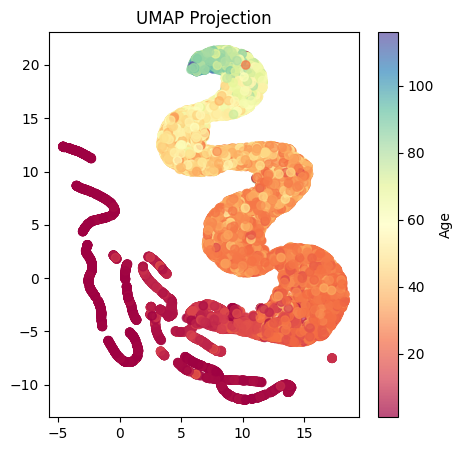

Training completed in: 34.38 seconds


In [7]:
start_time = time.time()
visualize({**config, **vis_config})
end_time = time.time()
print(f"Training completed in: {end_time - start_time:.2f} seconds")